In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv(r"C:\Users\megha\Downloads\Projects\Duplicate Pairs Recognition\train.csv")
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [4]:
df.isna().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [5]:
df.dropna(inplace = True)

In [6]:
df.isna().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
qid = np.concatenate((df['question1'].values, df['question2'].values))
qid = pd.Series(qid)
qid.value_counts()

What are the best ways to lose weight?                                             161
How can you look at someone's private Instagram account without following them?    120
How can I lose weight quickly?                                                     111
What's the easiest way to make money online?                                        88
Can you see who views your Instagram?                                               79
                                                                                  ... 
Which Professors from IIT Delhi would you love to see on Quora?                      1
How do you get red hair dye out of white tiles?                                      1
Do all the contestants on Survivor get paid?                                         1
What is the fastest way to sign into Yahoo Mail Classic?                             1
Why am I mentally very lonely? How can I solve it?                                   1
Name: count, Length: 537359, dtype: int64

In [9]:
print(f"number of unique questions: {np.unique(qid).shape[0]}")

number of unique questions: 537359


In [10]:
x = qid.value_counts() > 1
print(f"number of repeated question in the dataset: {x[x].shape[0]}")

number of repeated question in the dataset: 111870


<Axes: xlabel='is_duplicate'>

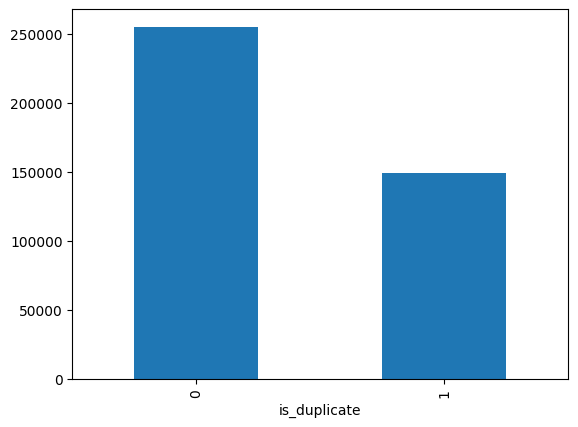

In [11]:
df['is_duplicate'].value_counts().plot(kind ='bar')

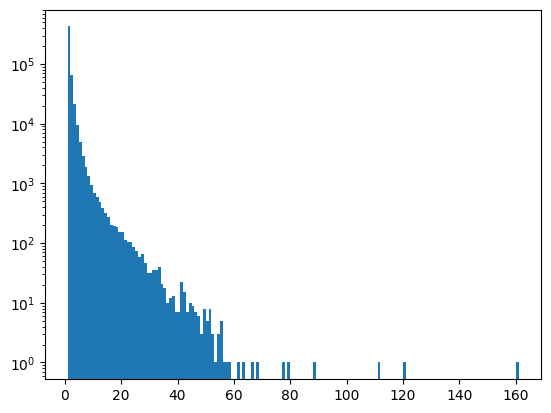

In [12]:
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

We are taking only 30000 questions as the data

In [13]:
new_df = df.sample(30000)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
36527,36527,66592,42096,What is it like to attend your high school reu...,What was it like to go to your high school reu...,1
84029,84029,142128,142129,Where can I get the US census data during the ...,What is the impact of the government shutdown?,0
7739,7739,15107,15108,What is the specific heat of ice?,What is the heat capacity of ice? How is this ...,1
92236,92236,154446,1241,What are some unusual aspects about politics a...,What are some unusual aspects about politics a...,0
385847,385847,11074,518012,Which country is better for an MS in computer ...,I am an Indian. Which country is a better choi...,1


In [14]:
new_df.reset_index(inplace = True)

In [16]:
new_df

,index,id,qid1,qid2,question1,question2,is_duplicate
0,36527,36527,66592,42096,What is it like to attend your high school reu...,What was it like to go to your high school reu...,1
1,84029,84029,142128,142129,Where can I get the US census data during the ...,What is the impact of the government shutdown?,0
2,7739,7739,15107,15108,What is the specific heat of ice?,What is the heat capacity of ice? How is this ...,1
3,92236,92236,154446,1241,What are some unusual aspects about politics a...,What are some unusual aspects about politics a...,0
4,385847,385847,11074,518012,Which country is better for an MS in computer ...,I am an Indian. Which country is a better choi...,1
...,...,...,...,...,...,...,...
29995,65418,65418,113540,113541,Are economic crises a price worth paying for l...,How have changing oil prices impacted US and g...,0
29996,329560,329560,456233,456234,Why do most sources say INFP is 4% of the popu...,Why do most sources put INFP frequency at abou...,1
29997,401177,401177,534566,534567,Does Canadian tire premium gas have ethanol in...,Accounting standards by jawaharlal?,0
29998,202020,202020,304179,104449,Why isn't the use of Torrent illegal?,Is torrent usage illegal?,1


In [18]:
new_df.drop(columns = ['index','qid1','qid2','id'],axis = 0,inplace = True)

In [19]:
new_df['is_duplicate'].value_counts(normalize = True)

is_duplicate
0    0.636333
1    0.363667
Name: proportion, dtype: float64

<Axes: xlabel='is_duplicate'>

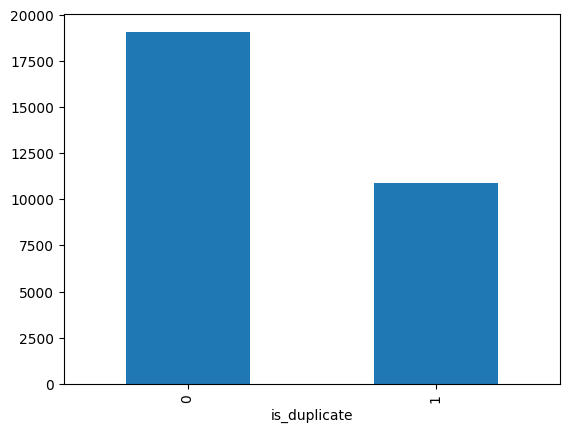

In [20]:
new_df['is_duplicate'].value_counts().plot(kind = 'bar')

In [21]:
qid1 = np.concatenate((new_df['question1'].values, new_df['question2'].values))
qid1 = pd.Series(qid1)
qid1.value_counts()

What are the best ways to lose weight?                                                                                                                                                          13
What do you think of the decision by the Indian Government to demonetize 500 and 1000 rupee notes?                                                                                              10
What is the easy way to make money online?                                                                                                                                                      10
How can you look at someone's private Instagram account without following them?                                                                                                                 10
How can I lose weight quickly?                                                                                                                                                                   8
                         

In [24]:
ques_df =  new_df[['question1','question2']]
ques_df

,question1,question2
0,What is it like to attend your high school reu...,What was it like to go to your high school reu...
1,Where can I get the US census data during the ...,What is the impact of the government shutdown?
2,What is the specific heat of ice?,What is the heat capacity of ice? How is this ...
3,What are some unusual aspects about politics a...,What are some unusual aspects about politics a...
4,Which country is better for an MS in computer ...,I am an Indian. Which country is a better choi...
...,...,...
29995,Are economic crises a price worth paying for l...,How have changing oil prices impacted US and g...
29996,Why do most sources say INFP is 4% of the popu...,Why do most sources put INFP frequency at abou...
29997,Does Canadian tire premium gas have ethanol in...,Accounting standards by jawaharlal?
29998,Why isn't the use of Torrent illegal?,Is torrent usage illegal?


In [25]:
questions = list(ques_df['question1']) + list(ques_df['question2'])

In [33]:
x = new_df.drop(columns ='is_duplicate')
y = new_df['is_duplicate']

In [34]:
x_train,x_val,y_train,y_val = train_test_split(x,y,test_size = 0.3,random_state = 42)

In [37]:
ques_tr = list(x_train['question1']) + list(x_train['question2'])
ques_tr = pd.Series(ques_tr)

In [40]:
tfidf = TfidfVectorizer(max_features = 3000)

In [41]:
q1_arr, q2_arr = np.vsplit(tfidf.fit_transform(ques_tr).toarray(),2)

In [45]:
q2_arr.shape

(21000, 3000)

In [46]:
temp_df1 = pd.DataFrame(q1_arr, index= x_train.index)
temp_df2 = pd.DataFrame(q2_arr, index= x_train.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
temp_df.shape

(21000, 6000)

In [47]:
ques_val = list(x_val['question1']) + list(x_val['question2'])
ques_val = pd.Series(ques_val)

In [48]:
q1_arr, q2_arr = np.vsplit(tfidf.transform(ques_val).toarray(),2)

In [49]:
temp_df1 = pd.DataFrame(q1_arr, index= x_val.index)
temp_df2 = pd.DataFrame(q2_arr, index= x_val.index)
temp_df_val = pd.concat([temp_df1, temp_df2], axis=1)
temp_df_val.shape

(9000, 6000)

Model Fitting

In [54]:
model = LogisticRegression()
model.fit(temp_df,y_train)
y_pred = model.predict(temp_df_val)
print(accuracy_score(y_val,y_pred))
print(classification_report(y_val,y_pred))

0.7227777777777777
              precision    recall  f1-score   support

           0       0.75      0.85      0.80      5751
           1       0.65      0.49      0.56      3249

    accuracy                           0.72      9000
   macro avg       0.70      0.67      0.68      9000
weighted avg       0.71      0.72      0.71      9000



In [55]:
model = RandomForestClassifier()
model.fit(temp_df,y_train)
y_pred = model.predict(temp_df_val)
print(accuracy_score(y_val,y_pred))
print(classification_report(y_val,y_pred))

0.7408888888888889
              precision    recall  f1-score   support

           0       0.74      0.92      0.82      5751
           1       0.76      0.42      0.54      3249

    accuracy                           0.74      9000
   macro avg       0.75      0.67      0.68      9000
weighted avg       0.74      0.74      0.72      9000

